# Exercises

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.optimize import minimize
import sys


sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})


print(sys.path)
sys.path.append('C:/Users/Beheerder/OneDrive/Documents/Radboud Universiteit/Master/Neuro Analysis/neural-data-master/Neuro_Analysis_def/2-single-cell-analysis-master/02-GLMs/code')


['c:\\Users\\Beheerder\\miniforge3\\python310.zip', 'c:\\Users\\Beheerder\\miniforge3\\DLLs', 'c:\\Users\\Beheerder\\miniforge3\\lib', 'c:\\Users\\Beheerder\\miniforge3', '', 'C:\\Users\\Beheerder\\AppData\\Roaming\\Python\\Python310\\site-packages', 'C:\\Users\\Beheerder\\AppData\\Roaming\\Python\\Python310\\site-packages\\win32', 'C:\\Users\\Beheerder\\AppData\\Roaming\\Python\\Python310\\site-packages\\win32\\lib', 'C:\\Users\\Beheerder\\AppData\\Roaming\\Python\\Python310\\site-packages\\Pythonwin', 'c:\\Users\\Beheerder\\miniforge3\\lib\\site-packages']


In [ ]:
#import supporting functions
from utilities import create_receptive_field

## Exercise 1
---
Determine the effect of stimulus sequence duration on RF estimates. To do this, repeat the above steps for different durations (5 s, 10 s, 20 s, 40 s, 80 s, 160 s, 320 s, 640 s). Compute the Pearson correlation between true and estimated RFs for each duration to quantify the accuracy of the estimator. The Pearson correlation $\mathrm{cc}$ is defined as
$$
\mathrm{cc} = \frac{\mathbf{k}_\mathrm{true}^T \hat{\mathbf{k}}}{\lVert \mathbf{k}_\mathrm{true} \rVert \lVert \hat{\mathbf{k}} \rVert}
$$
where $\lVert \cdot \rVert$ is the L2-norm (vector length).
As the response generation process is stochastic, compute the average correlation across 10 realizations for the same duration and plot the average correlation as a function of duration. How is the recording duration related to the ability to recover the true RF?

To do this, we have to do the same but create a loop for the code, see below. Just as in the lecture notes, we generated a stimulus, simulated the spiking responses using the linear-nonlinear Poisson model, estimated the RF and computed the Pearson's correlation between the real and estimated RF. What we see in the plot is that the average Pearson's correlation increases when we increase the stimulus duration. This makes sense and also correspond to what was said in the lecture, as with longer recordings, the model has access to more data, which improves the signal-to-noise ratio when estimating the RF. This allows the model to estimate a better fit for the RF.



In [39]:
#use generate linear data function but make sure it is adapted so that it doesn't return any negative outputs

def generate_data_linear_1(S, K, dt=0.1, offset=2.0, noise_variance=4, f_nonlin=lambda x: np.maximum(0, x)):
    n_bins = S.shape[0]
    X_flat = S.reshape(n_bins, -1)
    k_flat = K.flatten()

    # Linear projection + offset
    lin_output = X_flat @ k_flat + offset

    # Apply nonlinearity
    rate = f_nonlin(lin_output)

    # Add noise
    rate += np.sqrt(noise_variance) * np.random.randn(*rate.shape)

    # Clip negative or invalid values to ensure valid Poisson λ
    rate = np.clip(rate, 0, None)

    # Poisson spike generation
    spikes = np.random.poisson(rate * dt)

    return spikes, X_flat, K, rate


In [6]:
durations = [5, 10, 20, 40, 80, 160, 320, 640]
dt = .1
vf_size = (15,15)
repeats = 10

# Create a fixed ground truth receptive field
K_true = create_receptive_field()

avg_correlations = []

In [7]:
for duration in durations:
    n_bins = round(duration / dt)
    correlations = []

    for _ in range(repeats):
        # Generate Gaussian stimulus
        S = np.random.randn(n_bins, *vf_size)

        # Simulate spikes using the linear model
        spikes, X_flat, _, _ = generate_data_linear_1(S, K_true, dt)

        # Estimate the RF using least squares
        K_est_flat = np.linalg.pinv(X_flat) @ spikes
        K_est = K_est_flat.reshape(vf_size)

        # Compute Pearson correlation between true and estimated RFs
        cc = np.corrcoef(K_true.flatten(), K_est.flatten())[0, 1]
        correlations.append(cc)

    # Average over all repeats
    avg_correlations.append(np.mean(correlations))

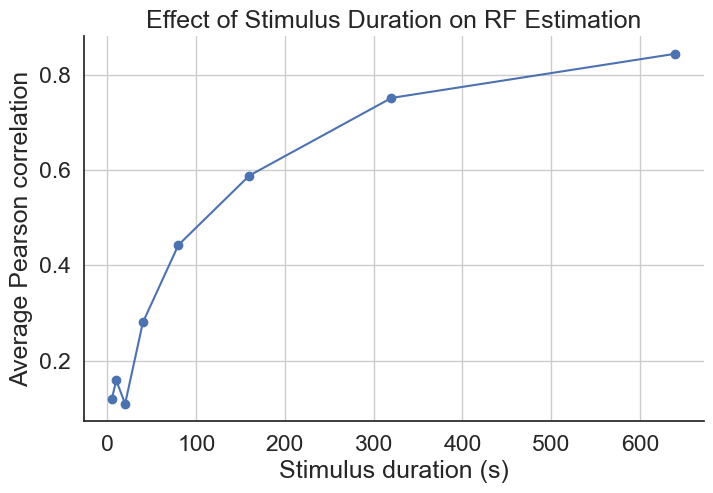

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(durations, avg_correlations, marker='o')
plt.xlabel('Stimulus duration (s)')
plt.ylabel('Average Pearson correlation')
plt.title('Effect of Stimulus Duration on RF Estimation')
plt.grid(True)
plt.show()

## Exercise 2
---

Determine the effect of response noise ($\sigma^2$) on RF estimates. Try different value for the noise variance in the simulations, e.g., 0, 2, 4, 6, 8, and 10 for a duration of 100 s. As in the previous excercise, repeatedly estimate RF parameters for each condition (10 times) but this time also plot the standard deviation of the correlations across the different runs for each condition.

In [9]:
duration = 100  # in seconds
dt = 0.1
std_dev = 1
vf_size = (15, 15)
repeats = 10
noise_levels = [0, 2, 4, 6, 8, 10]

# Create a true receptive field
K_true = create_receptive_field()
S = std_dev * np.random.randn(n_bins,vf_size[0],vf_size[1])

# Linear model 
def generate_data_linear_2(S, K, dt=0.1, offset=2.0, noise_variance=4, f_nonlin=lambda x: np.maximum(0, x)):
    n_bins = S.shape[0]
    X_flat = S.reshape(n_bins, -1)
    k_flat = K.flatten()

    lin_output = X_flat @ k_flat + offset
    rate = f_nonlin(lin_output)
    rate += np.sqrt(noise_variance) * np.random.randn(*rate.shape)
    rate = np.clip(rate, 0, None)
    spikes = np.random.poisson(rate * dt)

    return spikes, X_flat, K, rate

# Store results
avg_correlations = []
std_correlations = []

n_bins = round(duration / dt)

for noise_var in noise_levels:
    correlations = []

    for _ in range(repeats):
        # Generate stimulus
        S = np.random.randn(n_bins, *vf_size)

        # Simulate spike responses with current noise variance
        spikes, X_flat, _, _ = generate_data_linear_2(S, K_true, dt, noise_variance=noise_var)

        # Estimate RF
        K_est_flat = np.linalg.pinv(X_flat) @ spikes
        K_est = K_est_flat.reshape(vf_size)

        # Pearson correlation
        cc = np.corrcoef(K_true.flatten(), K_est.flatten())[0, 1]
        correlations.append(cc)

    # Store mean and std
    avg_correlations.append(np.mean(correlations))
    std_correlations.append(np.std(correlations))

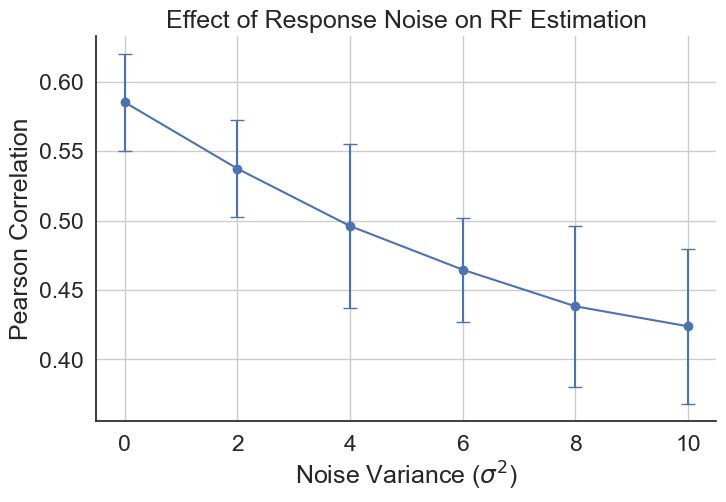

In [56]:
# Plotting
plt.figure(figsize=(8, 5))
plt.errorbar(noise_levels, avg_correlations, yerr=std_correlations, fmt='-o', capsize=5)
plt.xlabel('Noise Variance ($\sigma^2$)')
plt.ylabel('Pearson Correlation')
plt.title('Effect of Response Noise on RF Estimation')
plt.grid(True)
plt.show()


## Exercise 3
---
Look at the analytical derivation of the log-likelihood for the poisson GLM.
Which of the terms are required for maximizing the likelihood with respect to $\mathbf{k}$ and which terms can be ignored? **Note:** due to the independence of spikes in the different bins, the likelihood can be written as $P(R | S, \mathbf{k}) = \prod_t^T P(r_t | \mathbf{s}_t, \mathbf{k})$. The log turns the product into a sum which makes life much easier.  

When maximizing the log-likelihoood for the poisson GLM, we only care about the terms that depend on K

$r_t \log \Delta$ and $\log r_t!$ are constant terms that do not depend on k, leaving:

$$
\mathcal{L}(\mathbf{k}) = \sum_t \left[ r_t \mathbf{k}^\top \mathbf{s}_t - \Delta \exp(\mathbf{k}^\top \mathbf{s}_t) \right]
$$

The gradient of the log-likelihood with respect to $\mathbf{k}$ is:

$$
\frac{\partial \log P}{\partial \mathbf{k}} = \sum_t r_t \mathbf{s}_t - \Delta \sum_t \lambda_t \mathbf{s}_t
$$


## Exercise 4
---
Explore the effect of the data duration and the firing rate on the goodness of fit of the Poisson GLM.

A - Generate data with durations of 10,20,50,100 and 200 seconds. Fit the model on each dataset and plot the fitted parameters.
Use the pearson correlation as a proxy of the goodness of fit, and plot it as a function of the duration of the data.

B - Fix the duration to 100s, and change the average firing rate of the simulation. How does the fit perform for different firing rates? 

## A. Effect of duration

In [ ]:
# Parameters
durations = [10, 20, 50, 100, 200]
dt = 0.1
std_dev = 1
vf_size = (15, 15)
repeats = 5
noise_variance = 1
offset = 2.0
spike_rate = 5  # target average spike rate

In [32]:
# New function
def generate_data_poisson(S, K_true, offset, dt, target_rate):
    n_bins = S.shape[0]

    # Flatten and prepare stimulus
    S_flat = S.reshape(n_bins, -1)
    S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))  # add bias term

    # Flatten and add offset to RF
    K_flat = np.hstack((K_true.ravel(), offset))

    # Linear response
    lin_output = np.dot(S_flat, K_flat)

    # Nonlinear output (Poisson rate)
    lamda = np.exp(lin_output)

    # Adjust for target spike rate
    expected_rate = np.sum(lamda * dt) / (n_bins * dt)
    lamda *= target_rate / expected_rate

    # Generate spikes
    spike_counts = np.random.poisson(lam=lamda * dt)

    return spike_counts, S_flat


In [33]:
# Collect results
avg_correlations = []

for duration in durations:
    n_bins = int(duration / dt)
    correlations = []

    for _ in range(repeats):
        # Generate Gaussian stimulus
        S = std_dev * np.random.randn(n_bins, *vf_size)

        # Generate spike counts using Poisson model
        spike_counts, S_flat = generate_data_poisson(S, K_true, offset, dt, spike_rate)

        # Fit GLM (Poisson regression via least squares approximation)
        K_est_flat = np.linalg.pinv(S_flat) @ spike_counts
        K_est = K_est_flat[:-1].reshape(vf_size)  # exclude bias

        # Compute Pearson correlation
        cc = np.corrcoef(K_true.ravel(), K_est.ravel())[0, 1]
        correlations.append(cc)

    avg_corr = np.mean(correlations)
    avg_correlations.append(avg_corr)
    print(f"Duration: {duration}s | Avg. Pearson Correlation: {avg_corr:.3f}")

Duration: 10s | Avg. Pearson Correlation: 0.148
Duration: 20s | Avg. Pearson Correlation: 0.075
Duration: 50s | Avg. Pearson Correlation: 0.169
Duration: 100s | Avg. Pearson Correlation: 0.216
Duration: 200s | Avg. Pearson Correlation: 0.260


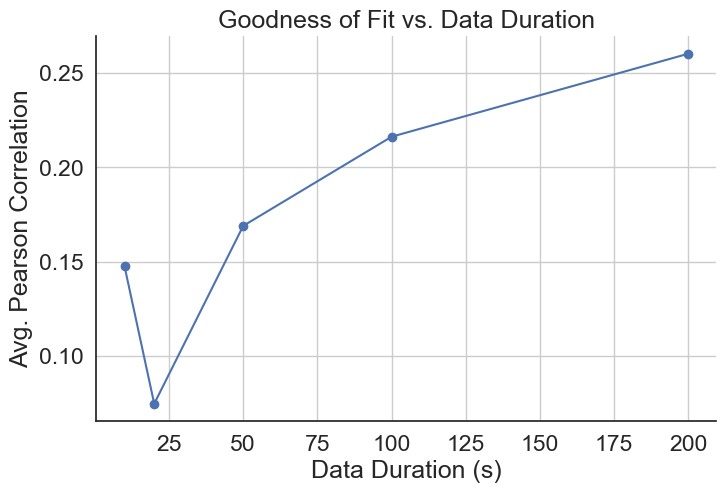

In [34]:
# Plot
plt.figure(figsize=(8, 5))
plt.plot(durations, avg_correlations, marker='o')
plt.xlabel("Data Duration (s)")
plt.ylabel("Avg. Pearson Correlation")
plt.title("Goodness of Fit vs. Data Duration")
plt.grid(True)
plt.show()

## B. Effect of firing rate

In [35]:
# Fixed parameters
duration = 100  # seconds
dt = 0.1
n_bins = int(duration / dt)
vf_size = (15, 15)
std_dev = 1
offset = 2.0
repeats = 5
noise_variance = 1

In [36]:
def generate_data_poisson(S, K_true, offset, dt, target_rate):
    n_bins = S.shape[0]

    # Flatten stimulus
    S_flat = S.reshape(n_bins, -1)
    S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))  # add bias

    # Linear filter
    K_flat = np.hstack((K_true.ravel(), offset))
    lin_output = np.dot(S_flat, K_flat)

    # Nonlinear output
    lamda = np.exp(lin_output)

    # Adjust to target firing rate
    expected_rate = np.sum(lamda * dt) / duration
    lamda *= target_rate / expected_rate

    # Simulate spike counts
    spike_counts = np.random.poisson(lamda * dt)

    return spike_counts, S_flat

In [37]:
firing_rates = [1, 2, 5, 10, 20, 50]
avg_correlations = []

for fr in firing_rates:
    correlations = []

    for _ in range(repeats):
        # Stimulus
        S = std_dev * np.random.randn(n_bins, *vf_size)

        # Simulate data
        spike_counts, S_flat = generate_data_poisson(S, K_true, offset, dt, fr)

        # Fit GLM
        K_est_flat = np.linalg.pinv(S_flat) @ spike_counts
        K_est = K_est_flat[:-1].reshape(vf_size)  # drop bias term

        # Compute Pearson correlation
        cc = np.corrcoef(K_true.ravel(), K_est.ravel())[0, 1]
        correlations.append(cc)

    avg_corr = np.mean(correlations)
    avg_correlations.append(avg_corr)
    print(f"Firing rate: {fr} Hz | Avg. Pearson Correlation: {avg_corr:.3f}")


Firing rate: 1 Hz | Avg. Pearson Correlation: 0.244
Firing rate: 2 Hz | Avg. Pearson Correlation: 0.237
Firing rate: 5 Hz | Avg. Pearson Correlation: 0.196
Firing rate: 10 Hz | Avg. Pearson Correlation: 0.214
Firing rate: 20 Hz | Avg. Pearson Correlation: 0.198
Firing rate: 50 Hz | Avg. Pearson Correlation: 0.198


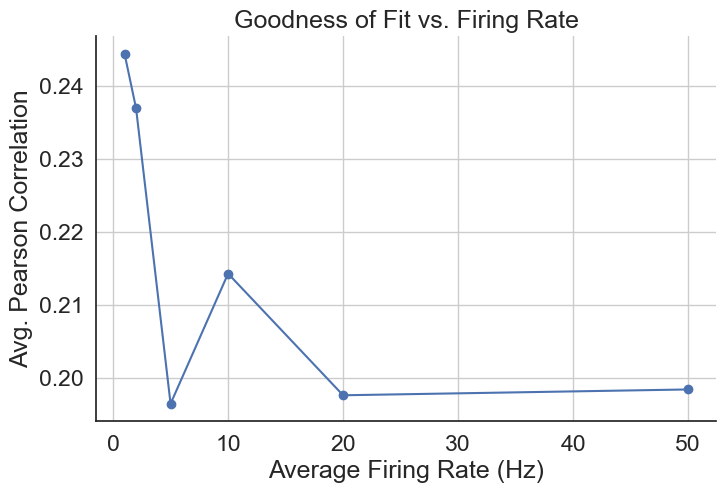

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(firing_rates, avg_correlations, marker='o')
plt.xlabel("Average Firing Rate (Hz)")
plt.ylabel("Avg. Pearson Correlation")
plt.title("Goodness of Fit vs. Firing Rate")
plt.grid(True)
plt.show()